# Vasicek Model: Parameter Estimation via MLE and Gaussian Transition Density

---

## 1. The Vasicek Model

The **Vasicek (1977)** model describes the evolution of the short-rate $r_t$ under the real-world measure $\mathbb{P}$:

$$dr_t = \kappa(\theta - r_t)\,dt + \sigma\,dW_t$$

where:
- $\kappa > 0$ — **speed of mean reversion** (how fast rates revert to long-run mean)
- $\theta$ — **long-run mean** (equilibrium level of interest rates)
- $\sigma > 0$ — **volatility** (instantaneous standard deviation)
- $W_t$ — standard Brownian motion

This is an **Ornstein-Uhlenbeck (OU)** process.

---

## 2. Analytical Solution (Exact Discretization)

For a fixed time step $\Delta t$, the **exact solution** of the SDE is:

$$r_{t+\Delta t} = r_t e^{-\kappa \Delta t} + \theta(1 - e^{-\kappa \Delta t}) + \sigma\sqrt{\frac{1 - e^{-2\kappa \Delta t}}{2\kappa}}\, Z$$

where $Z \sim \mathcal{N}(0,1)$ is independent.

Define:
$$\mu(r_t) = r_t e^{-\kappa \Delta t} + \theta(1 - e^{-\kappa \Delta t})$$
$$s^2 = \sigma^2 \frac{1 - e^{-2\kappa \Delta t}}{2\kappa}$$

So the **conditional distribution** (Gaussian transition density) is:

$$r_{t+\Delta t} \mid r_t \sim \mathcal{N}\!\left(\mu(r_t),\; s^2\right)$$

---

## 3. Gaussian Transition Density (Likelihood)

Given observations $\{r_0, r_1, \ldots, r_N\}$ at equally spaced times with step $\Delta t$, the **joint log-likelihood** factors into a product of transition densities (Markov property):

$$\mathcal{L}(\kappa,\theta,\sigma) = \sum_{i=1}^{N} \log f(r_i \mid r_{i-1}; \kappa, \theta, \sigma)$$

where each transition density is:

$$f(r_i \mid r_{i-1}) = \frac{1}{\sqrt{2\pi s^2}} \exp\!\left(-\frac{(r_i - \mu(r_{i-1}))^2}{2s^2}\right)$$

So the **log-likelihood** is:

$$\ell(\kappa, \theta, \sigma) = -\frac{N}{2}\log(2\pi) - \frac{N}{2}\log(s^2) - \frac{1}{2s^2}\sum_{i=1}^{N}\left(r_i - \mu(r_{i-1})\right)^2$$

---

## 4. MLE via Conditional Moments (Closed-Form)

We can also derive **closed-form MLE** estimates by defining auxiliary sums:

$$S_x = \sum_{i=1}^{N} r_{i-1}, \quad S_y = \sum_{i=1}^{N} r_i$$
$$S_{xx} = \sum_{i=1}^{N} r_{i-1}^2, \quad S_{yy} = \sum_{i=1}^{N} r_i^2, \quad S_{xy} = \sum_{i=1}^{N} r_{i-1}r_i$$

The MLE for the OU process (conditioning on $r_0$) yields:

$$\hat{\alpha} = \frac{S_{xy} - \frac{S_x S_y}{N}}{S_{xx} - \frac{S_x^2}{N}}, \quad \hat{\beta} = \frac{S_y - \hat{\alpha}S_x}{N}$$

$$\hat{s}^2 = \frac{1}{N}\left(S_{yy} - \hat{\alpha}S_{xy} - \hat{\beta}S_y + \hat{\beta}^2 N\right)$$

Wait — more directly, the conditional mean satisfies $r_i = \alpha \cdot r_{i-1} + \beta + \varepsilon_i$ where:

$$\alpha = e^{-\kappa\Delta t}, \quad \beta = \theta(1 - e^{-\kappa\Delta t}) = \theta(1-\alpha)$$

So inverting:
$$\hat{\kappa} = -\frac{\ln \hat{\alpha}}{\Delta t}, \quad \hat{\theta} = \frac{\hat{\beta}}{1 - \hat{\alpha}}, \quad \hat{\sigma} = \sqrt{\frac{2\hat{\kappa}\,\hat{s}^2}{1 - e^{-2\hat{\kappa}\Delta t}}}$$

---

## 5. Summary of Steps

1. Simulate $r_t$ using exact discretization
2. Define the Gaussian log-likelihood function
3. Maximize via **numerical optimization** (`scipy.optimize.minimize`)
4. Cross-check with **closed-form** MLE formulas
5. Compare estimated parameters to true parameters

---
## 6. Implementation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

# ── True Parameters ──────────────────────────────────────────────────────────
TRUE_KAPPA = 0.5     # speed of mean reversion
TRUE_THETA = 0.05    # long-run mean (5%)
TRUE_SIGMA = 0.02    # volatility
r0          = 0.03   # initial interest rate (3%)

# ── Simulation Settings ──────────────────────────────────────────────────────
T      = 10.0        # total time (years)
N      = 1000        # number of time steps
dt     = T / N       # time step
np.random.seed(42)

print(f"True Parameters  →  κ = {TRUE_KAPPA},  θ = {TRUE_THETA},  σ = {TRUE_SIGMA}")
print(f"Simulation       →  T = {T} years,  N = {N} steps,  Δt = {dt:.4f}")

True Parameters  →  κ = 0.5,  θ = 0.05,  σ = 0.02
Simulation       →  T = 10.0 years,  N = 1000 steps,  Δt = 0.0100


### 6.1 Simulate the Vasicek Process (Exact Discretization)

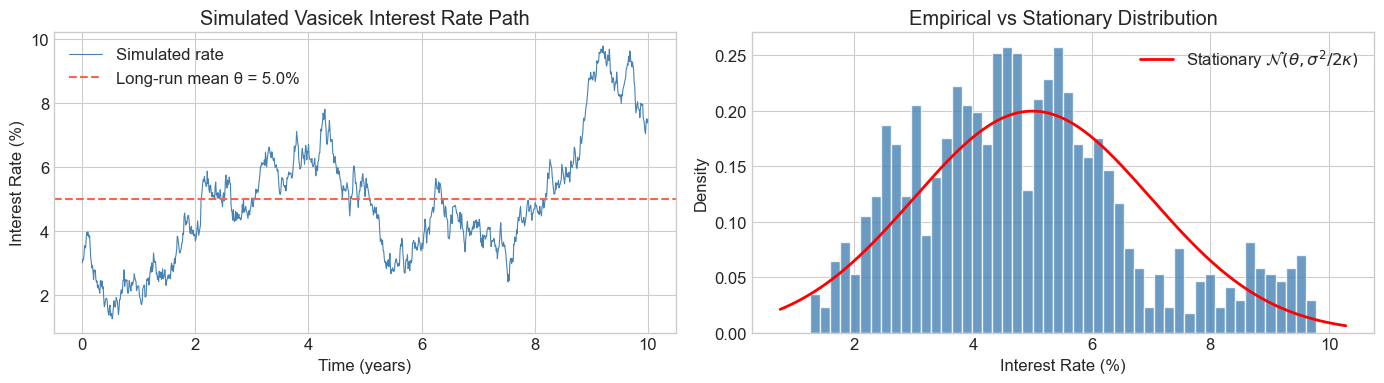

Rate statistics  →  mean = 0.0488,  std = 0.0189


In [2]:
def simulate_vasicek(kappa, theta, sigma, r0, T, N, seed=42):
    """
    Simulate Vasicek interest rate using exact discretization.
    
    r_{t+dt} = r_t * e^{-kappa*dt} + theta*(1 - e^{-kappa*dt})
              + sigma * sqrt((1 - e^{-2*kappa*dt}) / (2*kappa)) * Z
    """
    np.random.seed(seed)
    dt   = T / N
    r    = np.zeros(N + 1)
    r[0] = r0

    e1   = np.exp(-kappa * dt)
    e2   = np.exp(-2 * kappa * dt)
    cond_std = sigma * np.sqrt((1 - e2) / (2 * kappa))

    Z = np.random.standard_normal(N)
    for i in range(N):
        cond_mean = r[i] * e1 + theta * (1 - e1)
        r[i+1]   = cond_mean + cond_std * Z[i]
    
    t = np.linspace(0, T, N + 1)
    return t, r

# Simulate
t, r = simulate_vasicek(TRUE_KAPPA, TRUE_THETA, TRUE_SIGMA, r0, T, N)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(t, r * 100, color='steelblue', linewidth=0.8, label='Simulated rate')
axes[0].axhline(TRUE_THETA * 100, color='tomato', linestyle='--', label=f'Long-run mean θ = {TRUE_THETA*100:.1f}%')
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('Interest Rate (%)')
axes[0].set_title('Simulated Vasicek Interest Rate Path')
axes[0].legend()

axes[1].hist(r * 100, bins=50, color='steelblue', edgecolor='white', density=True, alpha=0.8)
# Overlay stationary distribution N(theta, sigma^2 / (2*kappa))
stat_std = TRUE_SIGMA / np.sqrt(2 * TRUE_KAPPA)
x = np.linspace(r.min()*100 - 0.5, r.max()*100 + 0.5, 300)
axes[1].plot(x, norm.pdf(x, TRUE_THETA*100, stat_std*100), 'r-', lw=2, label='Stationary $\\mathcal{N}(\\theta, \\sigma^2/2\\kappa)$')
axes[1].set_xlabel('Interest Rate (%)')
axes[1].set_ylabel('Density')
axes[1].set_title('Empirical vs Stationary Distribution')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f"Rate statistics  →  mean = {r.mean():.4f},  std = {r.std():.4f}")

### 6.2 Gaussian Transition Density Log-Likelihood

In [3]:
def vasicek_log_likelihood(params, r, dt):
    """
    Negative log-likelihood of the Vasicek model given observations r.

    L(κ,θ,σ) = Σ log f(r_i | r_{i-1})

    where  f(r_i | r_{i-1}) ~ N(cond_mean, cond_var)
           cond_mean = r_{i-1} * e^{-κΔt} + θ(1 - e^{-κΔt})
           cond_var  = σ² (1 - e^{-2κΔt}) / (2κ)
    """
    kappa, theta, sigma = params

    # Parameter constraints (must stay positive)
    if kappa <= 0 or sigma <= 0:
        return 1e10

    e1       = np.exp(-kappa * dt)
    e2       = np.exp(-2 * kappa * dt)
    cond_var = sigma**2 * (1 - e2) / (2 * kappa)

    r_prev = r[:-1]   # r_{i-1}
    r_curr = r[1:]    # r_i

    cond_mean = r_prev * e1 + theta * (1 - e1)
    residuals  = r_curr - cond_mean

    # Sum of log N(residual | 0, cond_var)
    N_obs  = len(residuals)
    log_lik = (-N_obs / 2) * np.log(2 * np.pi * cond_var) \
              - (1 / (2 * cond_var)) * np.sum(residuals**2)

    return -log_lik   # return NEGATIVE log-likelihood for minimization

# Quick test with true params
nll_true = vasicek_log_likelihood([TRUE_KAPPA, TRUE_THETA, TRUE_SIGMA], r, dt)
print(f"Negative log-likelihood at TRUE params:  {nll_true:.4f}")

Negative log-likelihood at TRUE params:  -4819.0281


### 6.3 MLE via Numerical Optimization

In [4]:
def mle_numerical(r, dt):
    """Maximize the Gaussian log-likelihood numerically using L-BFGS-B."""
    
    # Initial guess (rough estimates)
    init_params = [0.3, np.mean(r), np.std(np.diff(r)) / np.sqrt(dt)]
    
    bounds = [(1e-5, None),   # kappa > 0
              (None, None),   # theta unconstrained
              (1e-5, None)]   # sigma > 0
    
    result = minimize(
        vasicek_log_likelihood,
        init_params,
        args=(r, dt),
        method='L-BFGS-B',
        bounds=bounds,
        options={'maxiter': 10000, 'ftol': 1e-12, 'gtol': 1e-8}
    )
    
    return result.x, result

mle_params, opt_result = mle_numerical(r, dt)
mle_kappa, mle_theta, mle_sigma = mle_params

print("─" * 50)
print(f"{'Parameter':<12} {'True':>10} {'MLE (Numerical)':>18} {'Error (%)':>12}")
print("─" * 50)
for name, true_val, est_val in zip(['κ', 'θ', 'σ'],
                                    [TRUE_KAPPA, TRUE_THETA, TRUE_SIGMA],
                                    [mle_kappa, mle_theta, mle_sigma]):
    err = abs(est_val - true_val) / true_val * 100
    print(f"{name:<12} {true_val:>10.5f} {est_val:>18.5f} {err:>11.2f}%")
print("─" * 50)
print(f"\nOptimization converged: {opt_result.success}")
print(f"Max log-likelihood: {-opt_result.fun:.4f}")

──────────────────────────────────────────────────
Parameter          True    MLE (Numerical)    Error (%)
──────────────────────────────────────────────────
κ               0.50000            0.48859        2.28%
θ               0.05000            0.05794       15.88%
σ               0.02000            0.01957        2.13%
──────────────────────────────────────────────────

Optimization converged: True
Max log-likelihood: 4819.6714


### 6.4 Closed-Form MLE (OLS on Discretized Process)

In [5]:
def mle_closed_form(r, dt):
    """
    Closed-form MLE for Vasicek parameters.

    The conditional mean is linear:  r_i = alpha * r_{i-1} + beta + eps
    → OLS regression gives alpha = e^{-kappa*dt}, beta = theta*(1-alpha)
    """
    N   = len(r) - 1
    x   = r[:-1]   # r_{i-1}
    y   = r[1:]    # r_i

    Sx  = np.sum(x)
    Sy  = np.sum(y)
    Sxx = np.sum(x**2)
    Syy = np.sum(y**2)
    Sxy = np.sum(x * y)

    # OLS slope (alpha = e^{-kappa*dt})
    alpha_hat = (N * Sxy - Sx * Sy) / (N * Sxx - Sx**2)
    beta_hat  = (Sy - alpha_hat * Sx) / N

    # Conditional variance
    residuals = y - (alpha_hat * x + beta_hat)
    s2_hat    = np.sum(residuals**2) / N

    # Recover Vasicek parameters
    kappa_hat = -np.log(alpha_hat) / dt
    theta_hat = beta_hat / (1 - alpha_hat)
    sigma_hat = np.sqrt(s2_hat * 2 * kappa_hat / (1 - np.exp(-2 * kappa_hat * dt)))

    return kappa_hat, theta_hat, sigma_hat, alpha_hat, beta_hat, s2_hat

cf_kappa, cf_theta, cf_sigma, alpha_hat, beta_hat, s2_hat = mle_closed_form(r, dt)

print("─" * 60)
print(f"{'Parameter':<12} {'True':>10} {'Numerical MLE':>15} {'Closed-Form MLE':>17}")
print("─" * 60)
for name, true_val, num_val, cf_val in zip(
        ['κ', 'θ', 'σ'],
        [TRUE_KAPPA, TRUE_THETA, TRUE_SIGMA],
        [mle_kappa, mle_theta, mle_sigma],
        [cf_kappa, cf_theta, cf_sigma]):
    print(f"{name:<12} {true_val:>10.5f} {num_val:>15.5f} {cf_val:>17.5f}")
print("─" * 60)

print(f"\nIntermediate OLS estimates:")
print(f"  alpha (= e^{{-κΔt}})  : {alpha_hat:.6f}  (true: {np.exp(-TRUE_KAPPA*dt):.6f})")
print(f"  beta  (= θ(1-alpha)) : {beta_hat:.6f}  (true: {TRUE_THETA*(1-np.exp(-TRUE_KAPPA*dt)):.6f})")
print(f"  s²  (cond. variance) : {s2_hat:.8f}  (true: {TRUE_SIGMA**2*(1-np.exp(-2*TRUE_KAPPA*dt))/(2*TRUE_KAPPA):.8f})")

────────────────────────────────────────────────────────────
Parameter          True   Numerical MLE   Closed-Form MLE
────────────────────────────────────────────────────────────
κ               0.50000         0.48859           0.48859
θ               0.05000         0.05794           0.05794
σ               0.02000         0.01957           0.01957
────────────────────────────────────────────────────────────

Intermediate OLS estimates:
  alpha (= e^{-κΔt})  : 0.995126  (true: 0.995012)
  beta  (= θ(1-alpha)) : 0.000282  (true: 0.000249)
  s²  (cond. variance) : 0.00000381  (true: 0.00000398)


### 6.5 Likelihood Surface Visualization

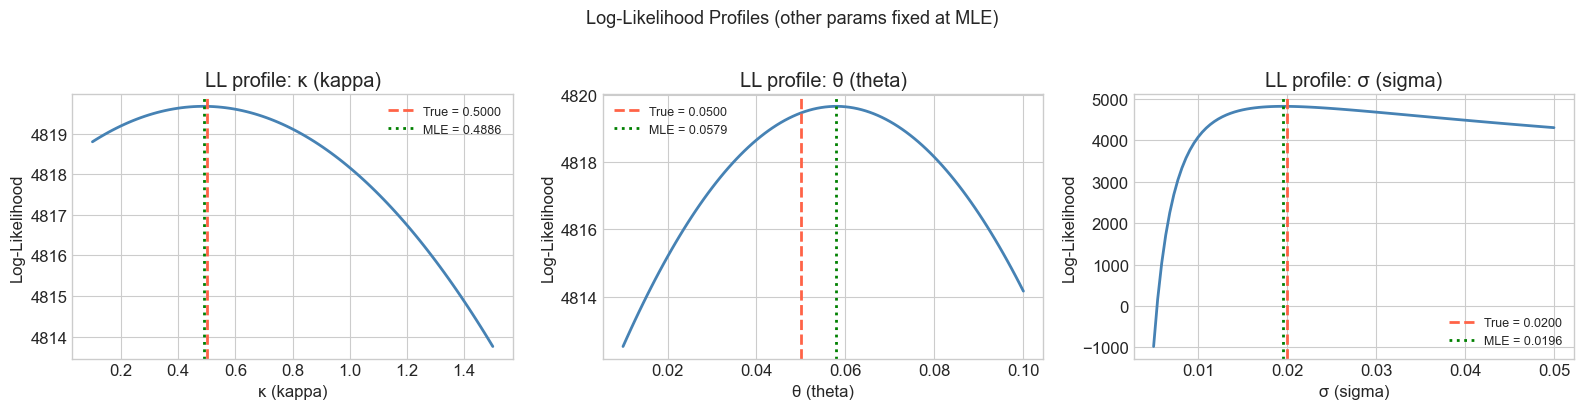

In [6]:
# Plot log-likelihood as a function of each parameter
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

param_names  = ['κ (kappa)', 'θ (theta)', 'σ (sigma)']
param_ranges = [
    np.linspace(0.1, 1.5, 100),
    np.linspace(0.01, 0.10, 100),
    np.linspace(0.005, 0.05, 100)
]
true_vals    = [TRUE_KAPPA, TRUE_THETA, TRUE_SIGMA]
mle_vals     = [cf_kappa, cf_theta, cf_sigma]
base_params  = [cf_kappa, cf_theta, cf_sigma]

for idx, (ax, name, grid, true, mle) in enumerate(
        zip(axes, param_names, param_ranges, true_vals, mle_vals)):
    
    log_liks = []
    for val in grid:
        p = base_params.copy()
        p[idx] = val
        ll = -vasicek_log_likelihood(p, r, dt)
        log_liks.append(ll)
    
    ax.plot(grid, log_liks, color='steelblue', lw=2)
    ax.axvline(true, color='tomato', linestyle='--', lw=2, label=f'True = {true:.4f}')
    ax.axvline(mle,  color='green',  linestyle=':',  lw=2, label=f'MLE = {mle:.4f}')
    ax.set_xlabel(name, fontsize=12)
    ax.set_ylabel('Log-Likelihood')
    ax.set_title(f'LL profile: {name}')
    ax.legend(fontsize=9)

plt.suptitle('Log-Likelihood Profiles (other params fixed at MLE)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 6.6 Model Validation: Fit vs. Simulated Data

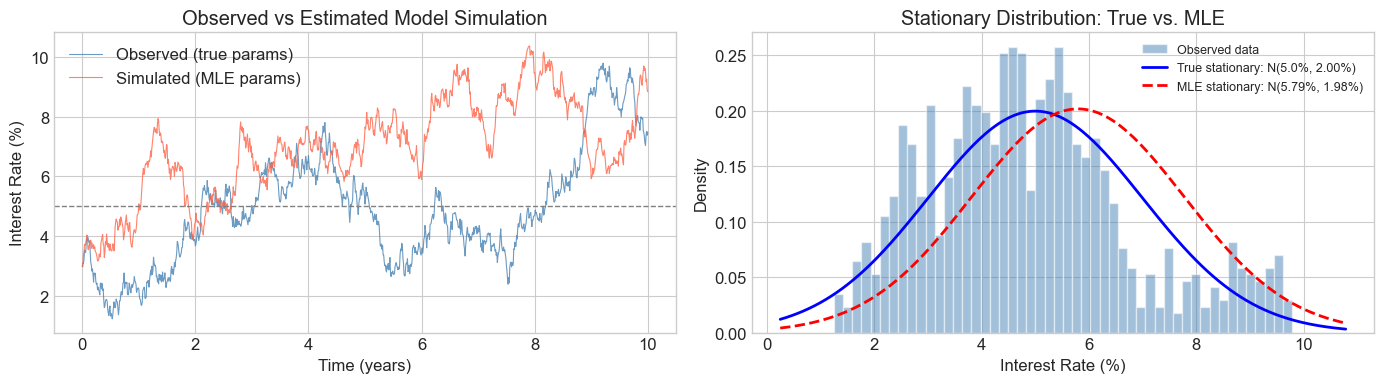

In [7]:
# Simulate with estimated parameters and compare
_, r_fit = simulate_vasicek(cf_kappa, cf_theta, cf_sigma, r0, T, N, seed=99)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Time series comparison
axes[0].plot(t, r * 100,     color='steelblue', alpha=0.8, lw=0.8, label='Observed (true params)')
axes[0].plot(t, r_fit * 100, color='tomato',    alpha=0.8, lw=0.8, label='Simulated (MLE params)')
axes[0].axhline(TRUE_THETA * 100, color='gray', linestyle='--', lw=1)
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('Interest Rate (%)')
axes[0].set_title('Observed vs Estimated Model Simulation')
axes[0].legend()

# Residual Q-Q style: empirical vs theoretical distribution
stat_std_true = TRUE_SIGMA / np.sqrt(2 * TRUE_KAPPA)
stat_std_mle  = cf_sigma / np.sqrt(2 * cf_kappa)
x_range = np.linspace(r.min()*100 - 1, r.max()*100 + 1, 300)

axes[1].hist(r * 100, bins=50, color='steelblue', edgecolor='white',
             density=True, alpha=0.5, label='Observed data')
axes[1].plot(x_range, norm.pdf(x_range, TRUE_THETA*100, stat_std_true*100),
             'b-', lw=2, label=f'True stationary: N({TRUE_THETA*100:.1f}%, {stat_std_true*100:.2f}%)')
axes[1].plot(x_range, norm.pdf(x_range, cf_theta*100, stat_std_mle*100),
             'r--', lw=2, label=f'MLE stationary: N({cf_theta*100:.2f}%, {stat_std_mle*100:.2f}%)')
axes[1].set_xlabel('Interest Rate (%)')
axes[1].set_ylabel('Density')
axes[1].set_title('Stationary Distribution: True vs. MLE')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

### 6.7 Residual Diagnostics

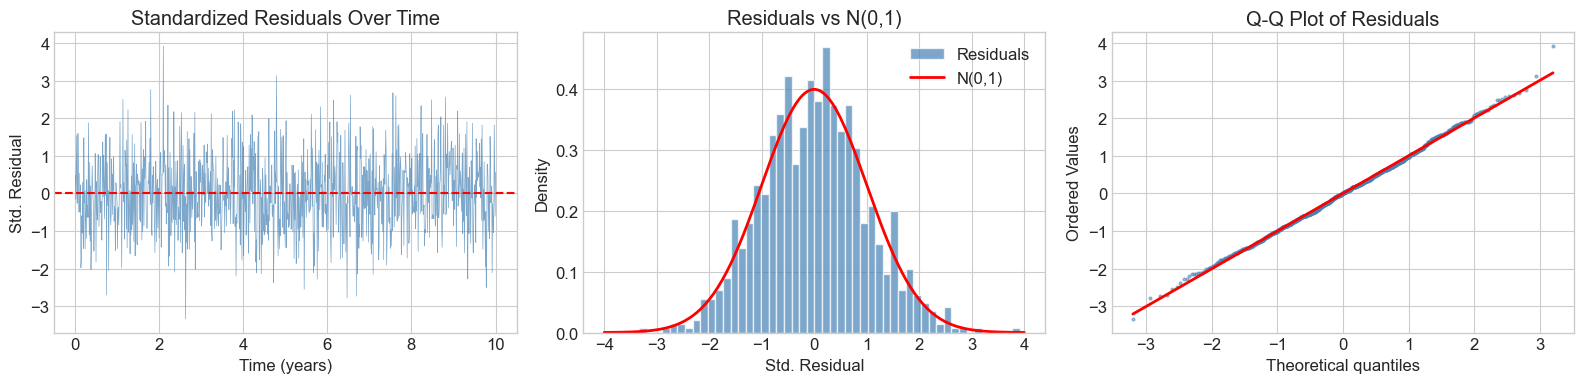

Residual statistics:
  Mean:     -0.00000  (expected ≈ 0)
  Std dev:  1.00000  (expected ≈ 1)
  Skewness: 0.11673  (expected ≈ 0)
  Kurtosis: 3.06643  (expected ≈ 3)


In [8]:
# Standardized residuals: eps_i = (r_i - cond_mean) / cond_std
e1_mle       = np.exp(-cf_kappa * dt)
e2_mle       = np.exp(-2 * cf_kappa * dt)
cond_var_mle = cf_sigma**2 * (1 - e2_mle) / (2 * cf_kappa)
cond_std_mle = np.sqrt(cond_var_mle)

cond_means = r[:-1] * e1_mle + cf_theta * (1 - e1_mle)
residuals  = (r[1:] - cond_means) / cond_std_mle  # standardized

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 1. Residual time series
axes[0].plot(t[1:], residuals, color='steelblue', lw=0.5, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Standardized Residuals Over Time')
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('Std. Residual')

# 2. Histogram of residuals vs N(0,1)
x_norm = np.linspace(-4, 4, 200)
axes[1].hist(residuals, bins=50, density=True, color='steelblue',
             edgecolor='white', alpha=0.7, label='Residuals')
axes[1].plot(x_norm, norm.pdf(x_norm), 'r-', lw=2, label='N(0,1)')
axes[1].set_title('Residuals vs N(0,1)')
axes[1].set_xlabel('Std. Residual')
axes[1].set_ylabel('Density')
axes[1].legend()

# 3. Q-Q plot
from scipy.stats import probplot
probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q Plot of Residuals')
axes[2].get_lines()[0].set(color='steelblue', markersize=2, alpha=0.5)
axes[2].get_lines()[1].set(color='red', lw=2)

plt.tight_layout()
plt.show()

print(f"Residual statistics:")
print(f"  Mean:     {residuals.mean():.5f}  (expected ≈ 0)")
print(f"  Std dev:  {residuals.std():.5f}  (expected ≈ 1)")
print(f"  Skewness: {((residuals - residuals.mean())**3).mean() / residuals.std()**3:.5f}  (expected ≈ 0)")
print(f"  Kurtosis: {((residuals - residuals.mean())**4).mean() / residuals.std()**4:.5f}  (expected ≈ 3)")

### 6.8 Effect of Sample Size on Estimation Quality

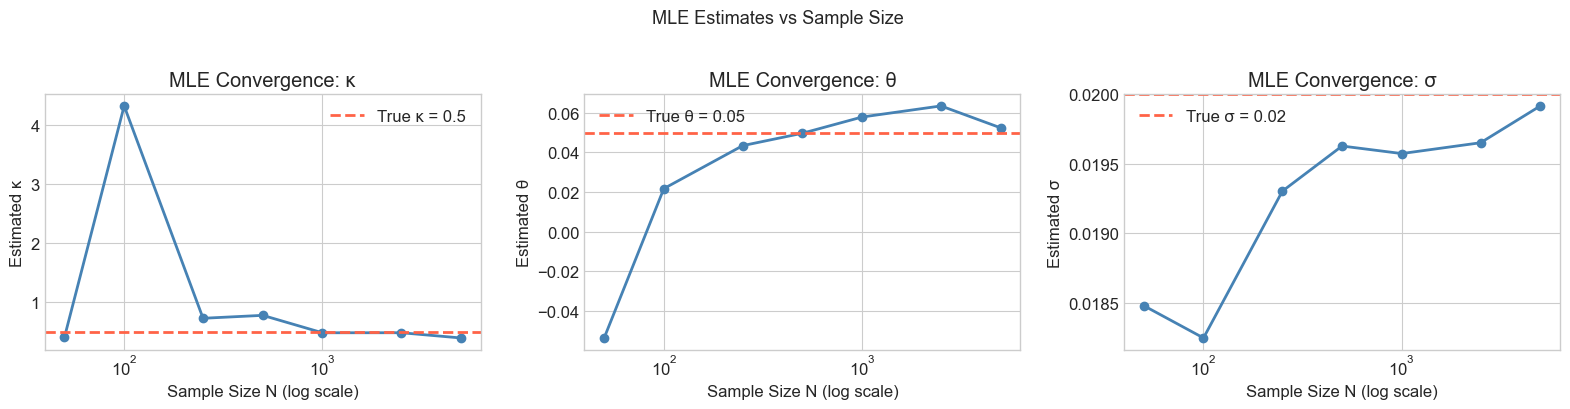

In [9]:
sample_sizes = [50, 100, 250, 500, 1000, 2500, 5000]

results = {'N': [], 'kappa': [], 'theta': [], 'sigma': []}

for n in sample_sizes:
    _, r_n = simulate_vasicek(TRUE_KAPPA, TRUE_THETA, TRUE_SIGMA, r0, T=n*dt, N=n, seed=42)
    k, th, s, *_ = mle_closed_form(r_n, dt)
    results['N'].append(n)
    results['kappa'].append(k)
    results['theta'].append(th)
    results['sigma'].append(s)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
param_info = [('kappa', 'κ', TRUE_KAPPA), ('theta', 'θ', TRUE_THETA), ('sigma', 'σ', TRUE_SIGMA)]

for ax, (key, label, true_val) in zip(axes, param_info):
    ax.semilogx(results['N'], results[key], 'o-', color='steelblue', lw=2, markersize=6)
    ax.axhline(true_val, color='tomato', linestyle='--', lw=2, label=f'True {label} = {true_val}')
    ax.set_xlabel('Sample Size N (log scale)')
    ax.set_ylabel(f'Estimated {label}')
    ax.set_title(f'MLE Convergence: {label}')
    ax.legend()

plt.suptitle('MLE Estimates vs Sample Size', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Final Summary

In [10]:
print("═" * 65)
print("  VASICEK MODEL — PARAMETER ESTIMATION SUMMARY")
print("═" * 65)
print(f"  Data: {N} observations over {T} years  (Δt = {dt:.4f})")
print("─" * 65)
print(f"{'Parameter':<10} {'True':>12} {'Numerical MLE':>15} {'Closed-Form MLE':>17}")
print("─" * 65)
rows = [
    ('κ', TRUE_KAPPA, mle_kappa, cf_kappa),
    ('θ', TRUE_THETA, mle_theta, cf_theta),
    ('σ', TRUE_SIGMA, mle_sigma, cf_sigma),
]
for name, true, num, cf in rows:
    print(f"{name:<10} {true:>12.6f} {num:>15.6f} {cf:>17.6f}")
print("─" * 65)

# Stationary distribution
stat_mean = cf_theta
stat_std  = cf_sigma / np.sqrt(2 * cf_kappa)
half_life = np.log(2) / cf_kappa

print(f"\n  Derived Properties (from MLE estimates):")
print(f"  Half-life of mean reversion: {half_life:.3f} years")
print(f"  Stationary mean:             {stat_mean*100:.3f}%")
print(f"  Stationary std dev:          {stat_std*100:.3f}%")
print(f"  95% stationary interval:     [{(stat_mean - 2*stat_std)*100:.2f}%, {(stat_mean + 2*stat_std)*100:.2f}%]")
print("═" * 65)

═════════════════════════════════════════════════════════════════
  VASICEK MODEL — PARAMETER ESTIMATION SUMMARY
═════════════════════════════════════════════════════════════════
  Data: 1000 observations over 10.0 years  (Δt = 0.0100)
─────────────────────────────────────────────────────────────────
Parameter          True   Numerical MLE   Closed-Form MLE
─────────────────────────────────────────────────────────────────
κ              0.500000        0.488589          0.488589
θ              0.050000        0.057942          0.057942
σ              0.020000        0.019573          0.019573
─────────────────────────────────────────────────────────────────

  Derived Properties (from MLE estimates):
  Half-life of mean reversion: 1.419 years
  Stationary mean:             5.794%
  Stationary std dev:          1.980%
  95% stationary interval:     [1.83%, 9.75%]
═════════════════════════════════════════════════════════════════


# Geometric Brownian Motion (GBM) — Parameter Estimation via Maximum Likelihood

---

## 1. Theoretical Background

### 1.1 The GBM Model

A stock price $S_t$ following GBM satisfies the stochastic differential equation:

$$dS_t = \mu S_t \, dt + \sigma S_t \, dW_t$$

where:
- $\mu$ = drift (annualized expected return)
- $\sigma$ = volatility (annualized standard deviation)
- $W_t$ = standard Brownian motion

By Itô's lemma, the exact solution is:

$$S_t = S_0 \exp\!\left[\left(\mu - \frac{\sigma^2}{2}\right)t + \sigma W_t\right]$$

---

### 1.2 Transition Density Function — Full Derivation

Step 1: Apply Itô's Lemma to $\ln S_t$

Let $f(S) = \ln S$. By Itô's lemma:

$$d(\ln S_t) = \frac{\partial f}{\partial S}\,dS_t + \frac{1}{2}\frac{\partial^2 f}{\partial S^2}(dS_t)^2$$

Computing the partial derivatives:
$$\frac{\partial f}{\partial S} = \frac{1}{S}, \qquad \frac{\partial^2 f}{\partial S^2} = -\frac{1}{S^2}$$

Substituting $dS_t = \mu S_t\,dt + \sigma S_t\,dW_t$ and using the Itô rule $(dW_t)^2 = dt$:

$$d(\ln S_t) = \frac{1}{S_t}(\mu S_t\,dt + \sigma S_t\,dW_t) + \frac{1}{2}\left(-\frac{1}{S_t^2}\right)\sigma^2 S_t^2\,dt$$

$$\boxed{d(\ln S_t) = \left(\mu - \frac{\sigma^2}{2}\right)dt + \sigma\,dW_t}$$

This is an ordinary SDE with constant coefficients — no $S_t$ dependence remains.

---

Step 2: Integrate over $[t_{i-1},\, t_i]$ with $\Delta t = t_i - t_{i-1}$

$$\ln S_{t_i} - \ln S_{t_{i-1}} = \left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma\,(W_{t_i} - W_{t_{i-1}})$$

Define the log-return $r_i = \ln(S_i / S_{i-1})$, so:

$$r_i = \left(\mu - \frac{\sigma^2}{2}\right)\Delta t + \sigma\,\Delta W_i$$

where $\Delta W_i = W_{t_i} - W_{t_{i-1}}$.

---

Step 3: Identify the distribution of $\Delta W_i$

By the independent increments property of Brownian motion:
$$\Delta W_i \sim \mathcal{N}(0,\, \Delta t)$$

Therefore $\sigma\,\Delta W_i \sim \mathcal{N}(0,\, \sigma^2 \Delta t)$, and since $(\mu - \sigma^2/2)\Delta t$ is a constant shift:

$$r_i \sim \mathcal{N}\!\left(\underbrace{\left(\mu - \frac{\sigma^2}{2}\right)\Delta t}_{\text{mean}},\;\underbrace{\sigma^2\Delta t}_{\text{variance}}\right)$$

---

Step 4: Write the density of $r_i$

Since $r_i$ is Gaussian with mean $m = (\mu - \sigma^2/2)\Delta t$ and variance $v = \sigma^2\Delta t$:

$$p(r_i;\,\mu,\sigma) = \frac{1}{\sqrt{2\pi\sigma^2\Delta t}}\exp\!\left[-\frac{\left(r_i - \left(\mu-\frac{\sigma^2}{2}\right)\Delta t\right)^2}{2\sigma^2\Delta t}\right]$$

Step 5: Change variable from $r_i$ to $S_i$ via the Jacobian

Since $r_i = \ln(S_i/S_{i-1})$, we have $\frac{\partial r_i}{\partial S_i} = \frac{1}{S_i}$, so $|\text{Jacobian}| = \frac{1}{S_i}$.

Applying the change-of-variable formula $p(S_i) = p(r_i)\cdot\left|\frac{\partial r_i}{\partial S_i}\right|$ yields the transition density:

$$\boxed{p(S_i \mid S_{i-1};\,\mu,\sigma) = \frac{1}{S_i\,\sigma\sqrt{2\pi\Delta t}}\exp\!\left[-\frac{\left(\ln(S_i/S_{i-1}) - \left(\mu-\frac{\sigma^2}{2}\right)\Delta t\right)^2}{2\sigma^2\Delta t}\right]}$$

This is the log-normal transition density: given $S_{i-1}$, the next price $S_i$ is log-normally distributed.

---

### 1.3 Likelihood Function

Given $n$ observations, the joint likelihood is the product of all transition densities (by the Markov property):

$$\mathcal{L}(\mu, \sigma) = \prod_{i=1}^{n} p(S_i \mid S_{i-1};\, \mu, \sigma)$$

---

### 1.4 Log-Likelihood Function

Taking the natural log (turns product into sum, easier to optimize):

$$\ell(\mu, \sigma) = -n\ln(\sigma) - \frac{n}{2}\ln(2\pi\Delta t) - \sum_{i=1}^{n}\ln(S_i) - \frac{1}{2\sigma^2 \Delta t}\sum_{i=1}^{n}\left(r_i - \left(\mu - \frac{\sigma^2}{2}\right)\Delta t\right)^2$$

---

### 1.5 Closed-Form MLE Estimates — Full Derivative Derivation

Let $\alpha = \mu - \sigma^2/2$ (the **log-drift**) and define the shorthand:
$$Q(\alpha, \sigma) = \sum_{i=1}^{n}\left(r_i - \alpha\,\Delta t\right)^2$$

The log-likelihood becomes:
$$\ell = -n\ln\sigma - \frac{n}{2}\ln(2\pi\Delta t) - \sum_i \ln S_i - \frac{Q}{2\sigma^2\Delta t}$$

---

Deriving $\hat{\alpha}$ (equivalently $\hat{\mu}$): differentiate w.r.t. $\alpha$

$$\frac{\partial \ell}{\partial \alpha} = -\frac{1}{2\sigma^2\Delta t}\cdot\frac{\partial Q}{\partial \alpha} = -\frac{1}{2\sigma^2\Delta t}\cdot(-2\Delta t)\sum_{i=1}^n(r_i - \alpha\,\Delta t)$$

$$= \frac{1}{\sigma^2}\sum_{i=1}^n(r_i - \alpha\,\Delta t)$$

Setting $\frac{\partial \ell}{\partial \alpha} = 0$:

$$\sum_{i=1}^n r_i = n\,\hat{\alpha}\,\Delta t \implies \hat{\alpha} = \frac{\bar{r}}{\Delta t}$$

where $\bar{r} = \frac{1}{n}\sum_{i=1}^n r_i$.

---

Deriving $\hat{\sigma}$: differentiate w.r.t. $\sigma$

$$\frac{\partial \ell}{\partial \sigma} = -\frac{n}{\sigma} + \frac{Q}{\sigma^3\,\Delta t}$$

Setting $\frac{\partial \ell}{\partial \sigma} = 0$:

$$\frac{Q}{\sigma^3\,\Delta t} = \frac{n}{\sigma} \implies \sigma^2 = \frac{Q}{n\,\Delta t}$$

Substituting back $Q$ evaluated at $\hat{\alpha} = \bar{r}/\Delta t$ (so $\hat{\alpha}\,\Delta t = \bar{r}$):

$$Q\big|_{\hat{\alpha}} = \sum_{i=1}^n(r_i - \bar{r})^2$$

Therefore:

$$\boxed{\hat{\sigma}^2 = \frac{1}{n\,\Delta t}\sum_{i=1}^n\left(r_i - \bar{r}\right)^2}$$

This is the MLE (biased) sample variance of log-returns, scaled by $\Delta t$ to annualise.

---

Recovering $\hat{\mu}$ from $\hat{\alpha}$

Since $\alpha = \mu - \sigma^2/2$, we have $\mu = \alpha + \sigma^2/2$, so:

$$\boxed{\hat{\mu} = \frac{\bar{r}}{\Delta t} + \frac{\hat{\sigma}^2}{2}}$$

Second-order check (concavity): The Hessian diagonal entries are $\frac{\partial^2 \ell}{\partial \alpha^2} = -n\Delta t/\sigma^2 < 0$ and $\frac{\partial^2 \ell}{\partial \sigma^2} = n/\sigma^2 - 3Q/(\sigma^4\Delta t) < 0$ at the optimum, confirming the stationary point is a global maximum.

---